In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('E:/CIENCIA DE DATOS E IA/2-SEGUNDO AÑO\SEGUNDO CUATRIMESTRE/2- LABORATORIO DE MINERIA Y DATOS/Proyecto_AndesLink/data/churn_sintetico.csv')
print(df.head())

   tenure_months  monthly_charge  total_charges  support_tickets  \
0              7           58.23         326.50                2   
1             56           56.75        3154.21                0   
2             48           78.84        3864.31                3   
3             32           79.74        2511.40                0   
4             32           55.37        1735.51                3   

   late_payments  avg_monthly_usage_gb contract_type payment_method  \
0              1                 81.83       mensual  transferencia   
1              2                 96.52         anual         debito   
2              2                 93.60       bianual       efectivo   
3              0                 28.95       bianual         debito   
4              0                126.90         anual       efectivo   

  internet_service  has_streaming  has_security_pack  num_products  region  \
0            cable              0                  1             3  centro   
1       

In [2]:
df.shape 

(5000, 16)

In [3]:
df.isnull().sum()

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
edad_maxima = df['customer_age'].max()
edad_minima = df['customer_age'].min()
print(f"La edad máxima de los clientes es: {edad_maxima}")
print(f"La edad máxima de los clientes es: {edad_minima}")

La edad máxima de los clientes es: 78
La edad máxima de los clientes es: 18


In [6]:
print (f"Cantidad de Clientes según el Tipo de Servicio")
servicios_top = df['internet_service'].value_counts()
print(servicios_top)

Cantidad de Clientes según el Tipo de Servicio
internet_service
fibra      2240
cable      1423
movil      1000
ninguno     337
Name: count, dtype: int64


In [7]:
Abandono_de_servicios = df['churn'].value_counts()
print (f"Cantidad Total de Clientes que Abandonaron (1)")
print(Abandono_de_servicios)

Cantidad Total de Clientes que Abandonaron (1)
churn
0    3298
1    1702
Name: count, dtype: int64


In [8]:
print (f"% de Abandono según el Tipo de Servicio")
print(df.groupby('internet_service')['churn'].mean() * 100)

% de Abandono según el Tipo de Servicio
internet_service
cable      34.785664
fibra      26.830357
movil      50.900000
ninguno    28.783383
Name: churn, dtype: float64


In [9]:
print (f"% de Abandono según el Tipo de Servicio")
print(df.groupby('has_security_pack')['churn'].mean() * 100)

% de Abandono según el Tipo de Servicio
has_security_pack
0    35.071708
1    33.160430
Name: churn, dtype: float64


In [10]:
print (f"% de Abandono según el Tipo de Servicio")
print(df.groupby('has_streaming')['churn'].mean() * 100)

% de Abandono según el Tipo de Servicio
has_streaming
0    34.578313
1    33.772455
Name: churn, dtype: float64


In [11]:
clientes_que_abandonan = df['churn'].value_counts()
print (f"% de Churn según el tipo de servicio")
print(df.groupby('internet_service')['churn'].mean() * 100)
print (f"Cantidad Total de Clientes que se fueron (1)")
print(clientes_que_abandonan)

% de Churn según el tipo de servicio
internet_service
cable      34.785664
fibra      26.830357
movil      50.900000
ninguno    28.783383
Name: churn, dtype: float64
Cantidad Total de Clientes que se fueron (1)
churn
0    3298
1    1702
Name: count, dtype: int64


In [12]:
# Primeras Observaciones:
# has_security Pack (35% vs 33%): La diferencia es mínima (solo 2%). Tener o no tener el paquete de seguridad no parece influir en que el cliente se quede o se vaya.
# has_reaming (34.5% vs 33.7%): Aquí la diferencia es de menos del 1%. Es prácticamente irrelevante.
# internet_service aquí tenemos el mayor porcentaje, la mitad de los que tienen este servicio se van.
# Cable: 34.7%
# Ninguno: 28.7%
# Fibra: 26.8%

In [13]:
# Filtramos el dataset original para quedarnos con TODA la información de esos clientes
df_ninguno_completo = df[df['internet_service'] == 'ninguno'].copy()

# Configuramos pandas para que nos deje ver todas las columnas si el dataset es ancho
import pandas as pd
pd.set_option('display.max_columns', None)

# Mostramos el dataset completo de estos 337 clientes
# (Aquí verás antigüedad, cargos, región, edad, y todos los servicios adicionales)
print(df_ninguno_completo)

# Si quieres ver un resumen rápido de qué servicios SÍ tienen contratados estos 337
# sin filtrar por mi cuenta, este comando te da el conteo de cada columna:
print("\nResumen de servicios para el grupo 'ninguno':")


      tenure_months  monthly_charge  total_charges  support_tickets  \
12               53           31.84        1531.23                1   
13               55           30.50        1724.31                2   
32                7           78.72         640.33                1   
35                5           49.14         390.33                0   
66               66           68.89        4576.71                2   
...             ...             ...            ...              ...   
4941             33           68.66        2425.99                6   
4952             57           51.24        2862.06                1   
4956             12           38.34         273.17                1   
4972             61           59.71        3772.73                2   
4974             58           68.86        4108.71                1   

      late_payments  avg_monthly_usage_gb contract_type payment_method  \
12                2                 40.14       mensual       efectivo   

C:\Users\resqu\AppData\Local\Temp\ipykernel_1628\1228897993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='viridis')


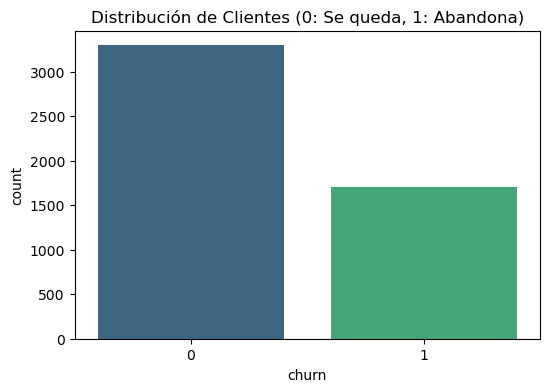

In [14]:
#1 Visualizar la distribución de Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribución de Clientes (0: Se queda, 1: Abandona)')
plt.show()

In [ ]:
#Distribución de Clientes (Gráfico de Barras)

# La gran mayoría de los clientes se mantienen (0), pero tenemos una cantidad significativa de abandonos (1), aproximadamente 1/3 abandono.

# Interpretación: Visualmente, parece que el churn representa aproximadamente un 30-35% de la base total.

# Para entrenar un modelo de Machine Learning más adelante, este "desbalance" es importante.
# Si el grupo 1 fuera mucho más pequeño, tendrías que usar técnicas especiales (como sobremuestreo), para que el modelo aprenda bien a identificar a los que se van.

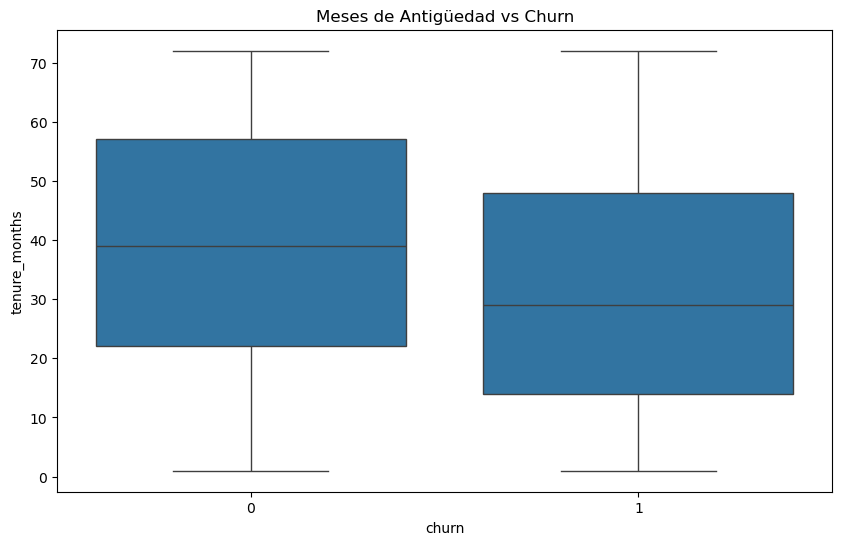

In [16]:
#2 Relación: Antigüedad vs Churn (Hipótesis: ¿los nuevos se van más?)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='churn', y='tenure_months')
plt.title('Meses de Antigüedad vs Churn')
plt.show()

In [17]:
# Meses de Antigüedad vs. Churn (Boxplot)

#Aquí comparamos la "lealtad" en tiempo. El boxplot muestra la mediana (la línea negra central) y la dispersión del 50% de los datos (la caja azul).

# Osea los clientes que se quedan (0) tienen una mediana de antigüedad notablemente más alta (cerca de los 40 meses), que los que se van (1) (cuya mediana está cerca de los 30 meses).

# La hipótesis de que "los nuevos se van más" parece ser correcta. 
# La caja del grupo 1 está más abajo en el eje Y, lo que indica que el riesgo de abandono es mayor durante los primeros dos años y medio de contrato.

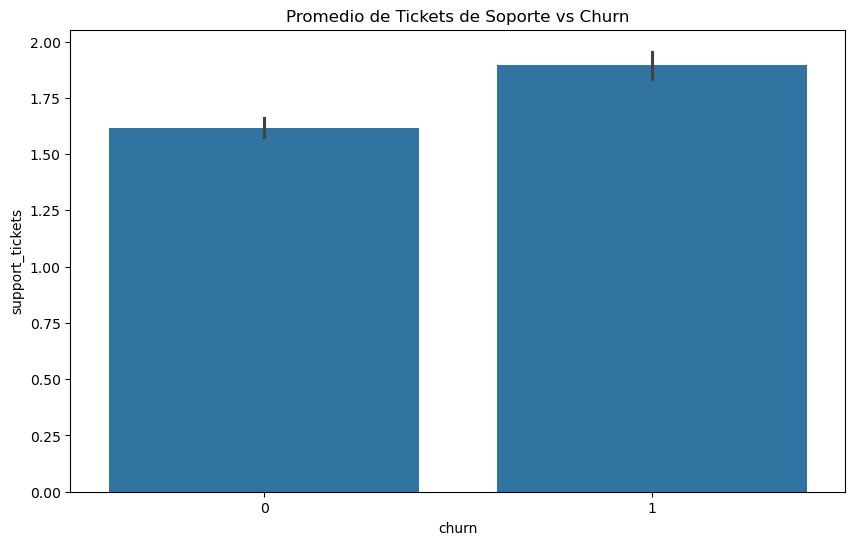

In [18]:
#3 Relación: Tickets de Soporte vs Churn
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='churn', y='support_tickets')
plt.title('Promedio de Tickets de Soporte vs Churn')
plt.show()

In [20]:
# Promedio de Tickets de Soporte vs. Churn

# Este gráfico muestra la relación entre la frustración técnica/administrativa y la salida del cliente.

# Existe una correlación clara. Los clientes que abandonan generan, en promedio, más tickets de soporte (cerca de 1.9) que los que se quedan (aprox. 1.6).

# La fricción en el servicio es un disparador del abandono.
# Las pequeñas líneas negras arriba de las barras (barras de error) son cortas,lo que significa que esta diferencia es estadísticamente significativa y no es fruto del azar.

In [ ]:
# Estrategia:

# Tenemos un problema de retención concentrado en los clientes más nuevos (menos de 30 meses), y en aquellos que experimentan problemas técnicos recurrentes (reflejado en el mayor volumen de tickets). 
# Para bajar el churn, deberíamos enfocarnos en mejorar la experiencia de soporte.
# Y crear planes de fidelización para los clientes que llevan menos de dos años con nosotros. 

In [22]:
# Conectamos con DagsHub
import dagshub
dagshub.init(repo_owner='JuanManuelResquin84', repo_name='Proyecto_AndesLink', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

Accessing as JuanManuelResquin84

Initialized MLflow to track repo "JuanManuelResquin84/Proyecto_AndesLink"

Repository JuanManuelResquin84/Proyecto_AndesLink initialized!

c:\Users\resqu\anaconda3\envs\churn_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/04/28 17:42:25 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning m

🏃 View run resilient-moth-782 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/b7e2ca38c14047ed93050752077e9445
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [23]:
# Preparamos los datos para el entrenamiento
import pandas as pd
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#1 Preparación de Datos (Copia y Limpieza)
df_ml = df.copy()

#2 Encoding
# Usamos One-Hot Encoding para las características (X)
# Esto crea columnas de 0 y 1 para categorías como 'plan_internet' o 'genero'
X = pd.get_dummies(df_ml.drop('churn', axis=1), drop_first=True)

#2 Usamos LabelEncoder solo para la variable objetivo (y)
le = LabelEncoder()
y = le.fit_transform(df_ml['churn'])

#3 División del Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Entrenamiento y Tracking con MLflow
with mlflow.start_run(run_name="RandomForest_OneHot_v1"):
    # Configuramos el modelo
    n_est = 100
    max_d = 5
    model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.7090

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       660
           1       0.70      0.25      0.37       340

    accuracy                           0.71      1000
   macro avg       0.70      0.60      0.59      1000
weighted avg       0.71      0.71      0.66      1000

🏃 View run RandomForest_OneHot_v1 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/95f2f330b90045e68a8026fc87c32e06
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [27]:
# Entrenamiento y Tracking con MLflow
with mlflow.start_run(run_name="RandomForest_OneHot_v1"):
    # Configuramos el modelo
    n_est = 60
    max_d = 5
    model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.7040

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       660
           1       0.68      0.25      0.36       340

    accuracy                           0.70      1000
   macro avg       0.69      0.59      0.58      1000
weighted avg       0.70      0.70      0.66      1000

🏃 View run RandomForest_OneHot_v1 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/5ec46455d875488d9f65932ca41dd9dd
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [28]:
# Entrenamiento y Tracking con MLflow
with mlflow.start_run(run_name="RandomForest_OneHot_v1"):
    # Configuramos el modelo
    n_est = 150
    max_d = 5
    model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.7160

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.72      0.94      0.81       660
           1       0.71      0.28      0.40       340

    accuracy                           0.72      1000
   macro avg       0.71      0.61      0.61      1000
weighted avg       0.71      0.72      0.67      1000

🏃 View run RandomForest_OneHot_v1 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/c57cc7edfb244583a8a062f30c50ffbf
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [29]:
# BALANCEO DE CLASES:ya que anteriormente el modelo trata a todos los errores por igual. 
# Agragando el parámetro class_weight='balanced' en tu RandomForest. Esto le dice al modelo que preste más atención a los clientes que abandonan.

with mlflow.start_run(run_name="RandomForest_Balanced_v2"):
    # Configuramos el modelo
    n_est = 150
    max_d = 7 
    
    # IMPORTANTE: El class_weight va dentro del constructor del modelo
    model = RandomForestClassifier(
        n_estimators=n_est, 
        max_depth=max_d, 
        class_weight='balanced', # <--- Ahora sí el modelo lo usa
        random_state=42
    )
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("class_weight", "balanced") # Agregamos esto al log para comparar
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.6770

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73       660
           1       0.52      0.68      0.59       340

    accuracy                           0.68      1000
   macro avg       0.66      0.68      0.66      1000
weighted avg       0.71      0.68      0.68      1000

🏃 View run RandomForest_Balanced_v2 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/25246e9589a44fe0a2b1da32844fc5e1
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0
